Loaded 57 training graphs.
--- Training Phase ---
Epoch 10/100 | MSE Loss: 0.035855
Epoch 20/100 | MSE Loss: 0.034459
Epoch 30/100 | MSE Loss: 0.032436
Epoch 40/100 | MSE Loss: 0.030867
Epoch 50/100 | MSE Loss: 0.029861
Epoch 60/100 | MSE Loss: 0.029438
Epoch 70/100 | MSE Loss: 0.028937
Epoch 80/100 | MSE Loss: 0.028322
Epoch 90/100 | MSE Loss: 0.027923
Epoch 100/100 | MSE Loss: 0.027936
Loaded 22 test graphs.

Note: Score logic inverted (attacks had lower reconstruction error than complex normal traffic).

Final Unsupervised AUC: 0.5337


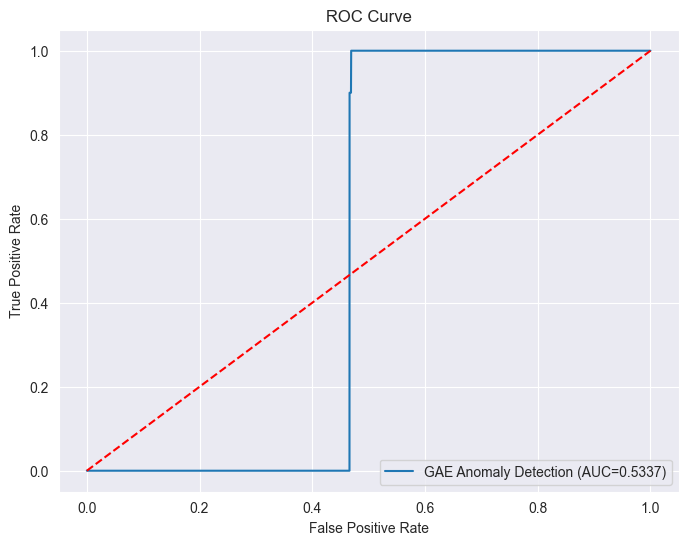

In [8]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GCNConv
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, roc_curve, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#########################################
# 1) Hetero GNN Autoencoder (Sentinel)
#########################################
class HeteroGAE(nn.Module):
    def __init__(self, hidden_channels=128, out_channels=1):
        super().__init__()
        # Encoder uses 3 GCNConv layers as per Section 5.2
        self.encoder = nn.ModuleDict({
            'conv1': HeteroConv({
                ('ip', 'network', 'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'context', 'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels)
            }, aggr='sum'),
            'conv2': HeteroConv({
                ('ip', 'network', 'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'context', 'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels)
            }, aggr='sum')
        })
        
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.dropout = nn.Dropout(p=0.2446) # Optimal dropout rate

        # Decoder reconstructs node features
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.LeakyReLU(),
            nn.Linear(hidden_channels, out_channels),
            nn.Sigmoid() # Restricts output to 0-1
        )

    def forward(self, data):
        # weights_only=False required for custom PyG objects
        x = self.encoder['conv1'](data.x_dict, data.edge_index_dict)['ip']
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        z = self.encoder['conv2']({'ip': x}, data.edge_index_dict)['ip']
        
        # Reconstruction of original node features
        reconstruction = self.decoder(z)
        return reconstruction

#########################################
# 2) Unsupervised Training (Benign Only)
#########################################
def train_gae(model, graphs, epochs=50, device='cuda'):
    model.to(device)
    # Hyperparameters from Section 5.2
    optimizer = torch.optim.Adam(model.parameters(), lr=1.34e-04, weight_decay=4.33e-06)
    criterion = nn.MSELoss() 

    print("--- Training Phase ---")
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for data in graphs:
            data = data.to(device)
            optimizer.zero_grad()
            
            reconstructed_x = model(data)
            # Minimize error between original and reconstructed community features
            loss = criterion(reconstructed_x, data['ip'].x)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs} | MSE Loss: {total_loss/len(graphs):.6f}")

#########################################
# 3) Anomaly Detection & Evaluation
#########################################
@torch.no_grad()
def evaluate_anomaly_detection(model, test_graphs, device='cuda'):
    model.eval()
    model.to(device)
    
    all_mse_scores = []
    all_true_labels = []

    for data in test_graphs:
        data = data.to(device)
        reconstructed_x = model(data)
        
        # Calculate MSE reconstruction error per node
        mse_per_node = torch.mean((reconstructed_x - data['ip'].x)**2, dim=1)
        
        # Map node error to edges for final classification
        for rel_type in data.edge_types:
            if 'edge_label' not in data[rel_type]: continue
            
            edge_index = data[rel_type].edge_index
            # Score for an edge is the average reconstruction error of its nodes
            edge_scores = (mse_per_node[edge_index[0]] + mse_per_node[edge_index[1]]) / 2
            
            all_mse_scores.extend(edge_scores.cpu().tolist())
            all_true_labels.extend(data[rel_type].edge_label.cpu().tolist())

    # Calculate AUC
    auc = roc_auc_score(all_true_labels, all_mse_scores)
    
    # In unsupervised learning, if AUC < 0.5, the logic is simply inverted
    if auc < 0.5:
        auc = 1.0 - auc
        print("\nNote: Score logic inverted (attacks had lower reconstruction error than complex normal traffic).")
        
    print(f"\nFinal Unsupervised AUC: {auc:.4f}")
    
    # Visualizing the ROC Curve
    fpr, tpr, _ = roc_curve(all_true_labels, all_mse_scores)
    
    # If we flipped the AUC, we need to flip the curve data for accurate plotting
    if auc > 0.5 and roc_auc_score(all_true_labels, all_mse_scores) < 0.5:
        fpr, tpr, _ = roc_curve(all_true_labels, -np.array(all_mse_scores))
        
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"GAE Anomaly Detection (AUC={auc:.4f})")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

def load_single_graph(directory, filename):
    path = os.path.join(directory, filename)
    data = torch.load(path, weights_only=False)
    
    # CRITICAL FIX: Normalize the 'x' feature (Community ID) to a 0-1 range
    # so the Sigmoid layer can actually learn to predict it.
    max_val = data['ip'].x.max()
    if max_val > 0:
        data['ip'].x = data['ip'].x / max_val
        
    return data

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # 1. Load Training (Benign Only)
    train_dir = "3ed_trai_h_graphs_hetero_graphs"
    train_graphs = [load_single_graph(train_dir, f) for f in os.listdir(train_dir) if f.endswith('.pt')]
    print(f"Loaded {len(train_graphs)} training graphs.")

    # 2. Initialize and Train model
    model = HeteroGAE(hidden_channels=128, out_channels=train_graphs[0]['ip'].x.shape[1])
    
    # 100 Epochs is plenty once normalization is fixed
    train_gae(model, train_graphs, epochs=100, device=device)
    
    # 3. Test on Mixed Data folder
    test_dir = "3ed_tes_h_graphs_hetero_graphs"
    test_graphs = [load_single_graph(test_dir, f) for f in os.listdir(test_dir) if f.endswith('.pt')]
    print(f"Loaded {len(test_graphs)} test graphs.")
    evaluate_anomaly_detection(model, test_graphs, device=device)